In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import gc
import numpy as np
from privacy_analysis.compute_privacy_sgm import compute_dp_sgd_privacy

transform = transforms.Compose([
    transforms.ToTensor(),  
])

mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(dataset=mnist_dataset, batch_size=64, shuffle=True)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.Resize((28, 28)),               
    transforms.ToTensor(),                       
])


fm_dataset  = datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
fm_loader  = DataLoader(dataset=fm_dataset, batch_size=1000, shuffle=False)

max_mnist_contribution = len(mnist_dataset) 
max_fm_contribution = len(fm_dataset) 
total_if_mnist_maxed = int(len(mnist_dataset) / 0.04)
total_if_fm_maxed = int(len(fm_dataset) / 0.96)
total_desired_size = min(total_if_mnist_maxed, total_if_fm_maxed)
mnist_size = int(0.04 * total_desired_size)
fm_size = int(0.96 * total_desired_size)
np.random.seed(42)
mnist_indices = np.random.choice(len(mnist_dataset), size=mnist_size, replace=False)
fm_indices = np.random.choice(len(fm_dataset), size=fm_size, replace=False)
mnist_subset = Subset(mnist_dataset, mnist_indices)
fm_subset = Subset(fm_dataset, fm_indices)
train_loader_public = DataLoader(dataset=mnist_subset, batch_size=64, shuffle=True)
train_loader_private = DataLoader(dataset=fm_subset, batch_size=64, shuffle=True)


test_dataset  = datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 273kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 32.2MB/s]


In [2]:
class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
epochs = 20
gc.collect()

20

In [3]:
def DOPESGD(model, D_loader, D_s_loader, test_loader, lr, sigma, C, l, T, delta):
    """
    Parameters:
        D_loader: private training data loader
        n: private batch size
        D_s_loader: public training data loader
        n_s: public batch size
        lr: learning rate
        sigma: noise scale
        C: gradient norm clip
        l: loss function
        T: number of training iterations
    """

    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    n_private = len(D_loader.dataset)
    batch_size_private = D_loader.batch_size
    
    optim = torch.optim.SGD(model.parameters(), lr)
    pub_iter = iter(D_s_loader)

    for epoch in range(T):
        
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for priv_inputs, priv_labels in D_loader:
            
            try:
                pub_inputs, pub_labels = next(pub_iter)
            except StopIteration:
                pub_iter = iter(D_s_loader)
                pub_inputs, pub_labels = next(pub_iter)
            
            optim.zero_grad()
            pub_out = model(pub_inputs)
            pub_loss = l(pub_out, pub_labels)
            pub_loss.backward()
            pub_grad = []
            for p in model.parameters():
                pub_grad.append(p.grad.detach().clone())
            pub_grad = [g.clone() for g in pub_grad]

            grads = [torch.zeros_like(p) for p in model.parameters()]

            for x, y in zip(priv_inputs, priv_labels):
                optim.zero_grad()
                output = model(x.unsqueeze(0))
                loss = l(output, y.unsqueeze(0))
                loss.backward()

                for i, p in enumerate(model.parameters()):
                    if p.requires_grad and p.grad is not None:
                        grads[i] += pub_grad[i] + ((p.grad - pub_grad[i]) * C) / (torch.max(torch.tensor(C), torch.norm(p.grad - pub_grad[i])))

                for i in range(len(grads)):    
                    grads[i] += torch.normal(0, sigma * C, grads[i].shape)

            for p, g in zip(model.parameters(), grads):
                if p.requires_grad:
                    p.grad = g / len(priv_inputs)
            optim.step()

            total_loss += pub_loss.item() * priv_inputs.size(0)
            with torch.no_grad():
                priv_out = model(priv_inputs)
                _, predicted = torch.max(priv_out.data, 1)
                total += priv_labels.size(0)
                correct += (predicted == priv_labels).sum().item()
        
        epoch_loss = total_loss / total
        epoch_accuracy = 100 * correct / total

        model.eval()
        correct = 0
        total = 0
        test_loss = 0.0

        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = l(outputs, labels)
                test_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total
        test_loss = test_loss / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        eps, _ = compute_dp_sgd_privacy(n_private, batch_size_private, sigma, epoch + 1, delta)

        print(f"Epoch [{epoch+1}/{T}] ... Training Loss: {epoch_loss:.4f} ... Training Accuracy: {epoch_accuracy:.2f}% ... Test Loss: {test_loss:.4f} ... Test Accuracy: {test_accuracy:.2f}% ... Epsilon: {eps:.4f} ... Delta: {delta}")

    return train_losses, train_accuracies, test_losses, test_accuracies

In [4]:
train_losses, train_accuracies, test_losses, test_accuracies = DOPESGD(
                                                                        model=model,
                                                                        D_loader=train_loader_private,
                                                                        D_s_loader=train_loader_public,
                                                                        test_loader=test_loader,
                                                                        lr=0.01,           
                                                                        sigma=0.7, 
                                                                        C=1.0, 
                                                                        l=criterion,
                                                                        T=epochs,
                                                                        delta=1e-5
                                                                      )

DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.7 iterated over 938 steps satisfies differential privacy with eps = 1.68 and delta = 1e-05.
The optimal RDP order is 6.5.
Epoch [1/20] ... Training Loss: 2.1140 ... Training Accuracy: 37.66% ... Test Loss: 1.4621 ... Test Accuracy: 45.00% ... Epsilon: 1.6750 ... Delta: 1e-05
DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.7 iterated over 1875 steps satisfies differential privacy with eps = 1.76 and delta = 1e-05.
The optimal RDP order is 6.5.
Epoch [2/20] ... Training Loss: 0.9754 ... Training Accuracy: 49.16% ... Test Loss: 1.2601 ... Test Accuracy: 52.63% ... Epsilon: 1.7641 ... Delta: 1e-05
DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.7 iterated over 2813 steps satisfies differential privacy with eps = 1.85 and delta = 1e-05.
The optimal RDP order is 6.5.
Epoch [3/20] ... Training Loss: 0.5142 ... Training Accuracy: 57.11% ... Test Loss: 1.0786 ... Test Accuracy: 60.16% ... Epsilon: 1.8533 ... Del

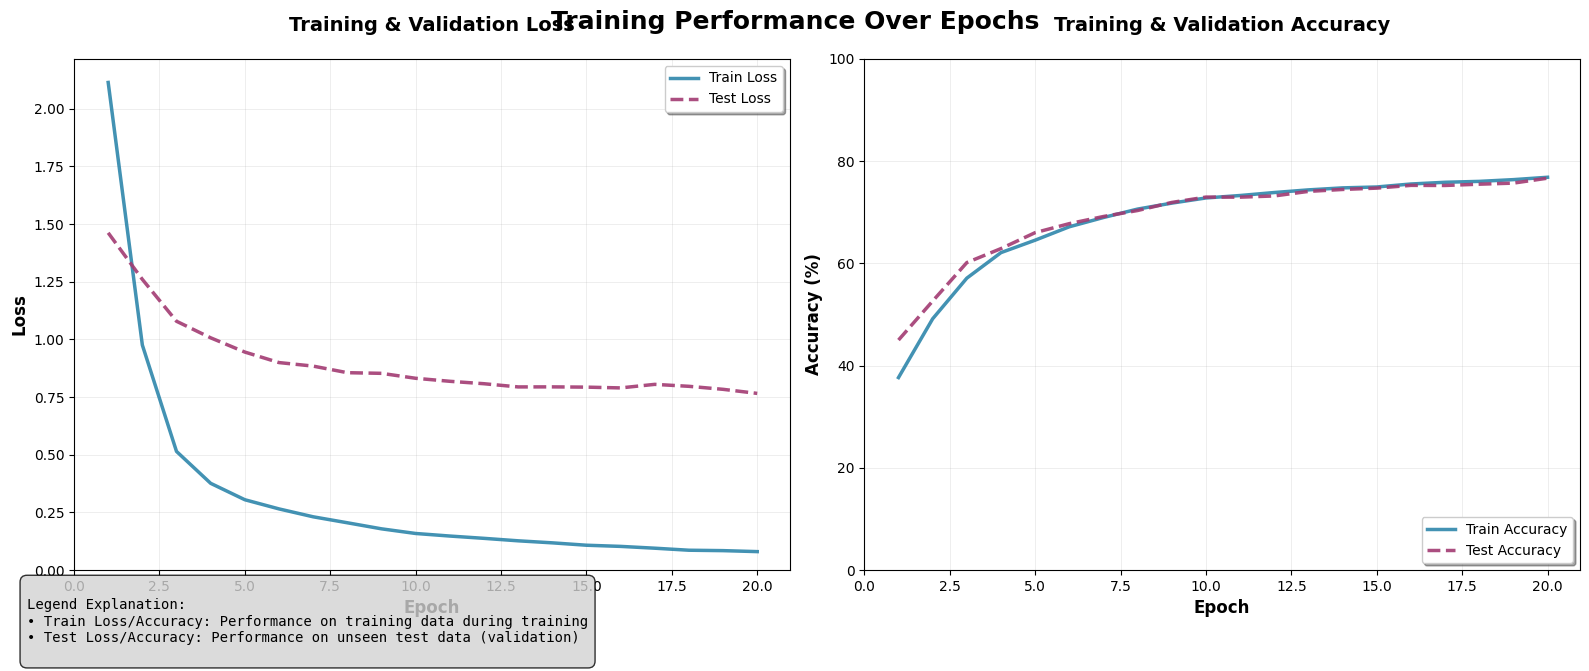

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Create epoch range
epochs = len(train_losses)
epoch_range = list(range(1, epochs + 1))

# Set up the figure
plt.rcParams.update({'font.size': 10})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define color palette
train_color = '#2E86AB'     # Blue
test_color = '#A23B72'      # Red/Purple

# --- Loss Plot ---
ax1.plot(epoch_range, train_losses, color=train_color, linewidth=2.5, 
         label='Train Loss', alpha=0.9)
ax1.plot(epoch_range, test_losses, color=test_color, linewidth=2.5, 
         linestyle='--', label='Test Loss', alpha=0.9)

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
ax2.plot(epoch_range, train_accuracies, color=train_color, linewidth=2.5, 
         label='Train Accuracy', alpha=0.9)
ax2.plot(epoch_range, test_accuracies, color=test_color, linewidth=2.5, 
         linestyle='--', label='Test Accuracy', alpha=0.9)

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Overall title
fig.suptitle('Training Performance Over Epochs', 
             fontsize=18, fontweight='bold', y=0.95)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.15)

# Glossary box (adjusted for simpler context)
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
"""

props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure
# plt.savefig('training_results.png', dpi=300, bbox_inches='tight', facecolor='white')